## **Dataset:** SPRSound (SJTU Paediatric Respiratory Sound Database)
### **Source:** IEEE BioCAS Grand Challenge
### **Total Recordings:** 2,683 (official)
### **Structure:** Organized by year (2022-2025) with separate JSON and WAV folders

## 1. Setup and Imports

In [28]:
import os
import sys
import json
import re
import librosa
import librosa.display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from collections import Counter
from tqdm import tqdm

# Add project root to path
sys.path.append('..')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Create figures directory
figures_dir = Path("../reports/figures/sprsound")
figures_dir.mkdir(parents=True, exist_ok=True)

# Define path
SPRSound_PATH = Path("../sound_data/sprsound")
print(f"SPRSound folder exists: {SPRSound_PATH.exists()}")

SPRSound folder exists: True


## 2. Map the Complex Structure

In [29]:
def find_all_files(base_path):
    wav_files = []
    json_files = []
    
    for root, dirs, files in os.walk(base_path):
        for file in files:
            full_path = Path(root) / file
            if file.endswith('.wav'):
                wav_files.append(full_path)
            elif file.endswith('.json'):
                json_files.append(full_path)
    
    return wav_files, json_files

wav_files, json_files = find_all_files(SPRSound_PATH)

print(f"\nFound {len(wav_files)} .wav files")
print(f"Found {len(json_files)} .json files")

# Show sample files
print("\n Sample audio files:")
for f in list(wav_files)[:5]:
    print(f"   - {f.relative_to(SPRSound_PATH)}")

print("\n Sample annotation files:")
for f in list(json_files)[:5]:
    print(f"   - {f.relative_to(SPRSound_PATH)}")


Found 6567 .wav files
Found 6567 .json files

 Sample audio files:
   - test\BioCAS2022\test2022_wav\40512331_8.1_1_p1_3544.wav
   - test\BioCAS2022\test2022_wav\40512331_8.1_1_p1_3548.wav
   - test\BioCAS2022\test2022_wav\40512331_8.1_1_p1_3552.wav
   - test\BioCAS2022\test2022_wav\40512331_8.1_1_p2_3545.wav
   - test\BioCAS2022\test2022_wav\40512331_8.1_1_p4_3543.wav

 Sample annotation files:
   - test\BioCAS2022\test2022_json\inter_test_json\40512331_8.1_1_p1_3544.json
   - test\BioCAS2022\test2022_json\inter_test_json\40512331_8.1_1_p1_3548.json
   - test\BioCAS2022\test2022_json\inter_test_json\40512331_8.1_1_p1_3552.json
   - test\BioCAS2022\test2022_json\inter_test_json\40512331_8.1_1_p2_3545.json
   - test\BioCAS2022\test2022_json\inter_test_json\40512331_8.1_1_p4_3543.json


## 3. Parse Filename Information

In [30]:
def parse_sprsound_filename(file_path):
    # Parse SPRSound filename to extract metadata
    filename = file_path.stem
    
    # Handle files that might start with underscore
    if filename.startswith('_'):
        filename = filename[1:]
    
    parts = filename.split('_')
    
    # Expected format: [patient]_[age]_[gender]_[location]_[recording]
    if len(parts) >= 5:
        try:
            info = {
                'filename': file_path.name,
                'patient_id': parts[0],
                'age': float(parts[1]) if parts[1].replace('.','').isdigit() else None,
                'gender': parts[2],
                'location': parts[3],
                'recording_id': parts[4],
                'year': file_path.parent.parent.parent.name if 'BioCAS' in str(file_path) else 'unknown',
                'split': 'test' if 'test' in str(file_path).lower() else 'train',
                'full_path': str(file_path)
            }
            return info
        except:
            return None
    return None

# Parse all WAV files
file_info = []
for f in wav_files:
    info = parse_sprsound_filename(f)
    if info:
        file_info.append(info)

df_files = pd.DataFrame(file_info)
print(f"\n Parsed {len(df_files)} files")
df_files.head()


 Parsed 6177 files


,filename,patient_id,age,gender,location,recording_id,year,split,full_path
0,40512331_8.1_1_p1_3544.wav,40512331,8.1,1,p1,3544,test,test,..\sound_data\sprsound\test\BioCAS2022\test202...
1,40512331_8.1_1_p1_3548.wav,40512331,8.1,1,p1,3548,test,test,..\sound_data\sprsound\test\BioCAS2022\test202...
2,40512331_8.1_1_p1_3552.wav,40512331,8.1,1,p1,3552,test,test,..\sound_data\sprsound\test\BioCAS2022\test202...
3,40512331_8.1_1_p2_3545.wav,40512331,8.1,1,p2,3545,test,test,..\sound_data\sprsound\test\BioCAS2022\test202...
4,40512331_8.1_1_p4_3543.wav,40512331,8.1,1,p4,3543,test,test,..\sound_data\sprsound\test\BioCAS2022\test202...


## 4. Basic Dataset Statistics

In [31]:
print("\n" + "="*60)
print("BASIC DATASET STATISTICS")
print("="*60)

print(f"Total recordings: {len(df_files)}")
print(f"Unique patients: {df_files['patient_id'].nunique()}")
print(f"Age range: {df_files['age'].min():.1f} - {df_files['age'].max():.1f} years")
print(f"Gender distribution: {df_files['gender'].value_counts().to_dict()}")
print(f"Recording locations: {df_files['location'].unique().tolist()}")
print(f"Years represented: {df_files['year'].unique().tolist()}")
print(f"Train/Test split: {df_files['split'].value_counts().to_dict()}")


BASIC DATASET STATISTICS
Total recordings: 6177
Unique patients: 868
Age range: 0.0 - 55.0 years
Gender distribution: {'0': 3323, '1': 2854}
Recording locations: ['p1', 'p2', 'p4', 'p3']
Years represented: ['test', 'unknown']
Train/Test split: {'test': 4228, 'train': 1949}


## 5. Visualizations_1

 ### Visualization 1: Age Distribution


Visualization 1: Age Distribution
Age in months - Min: 0.0, Max: 660.0, Mean: 66.5


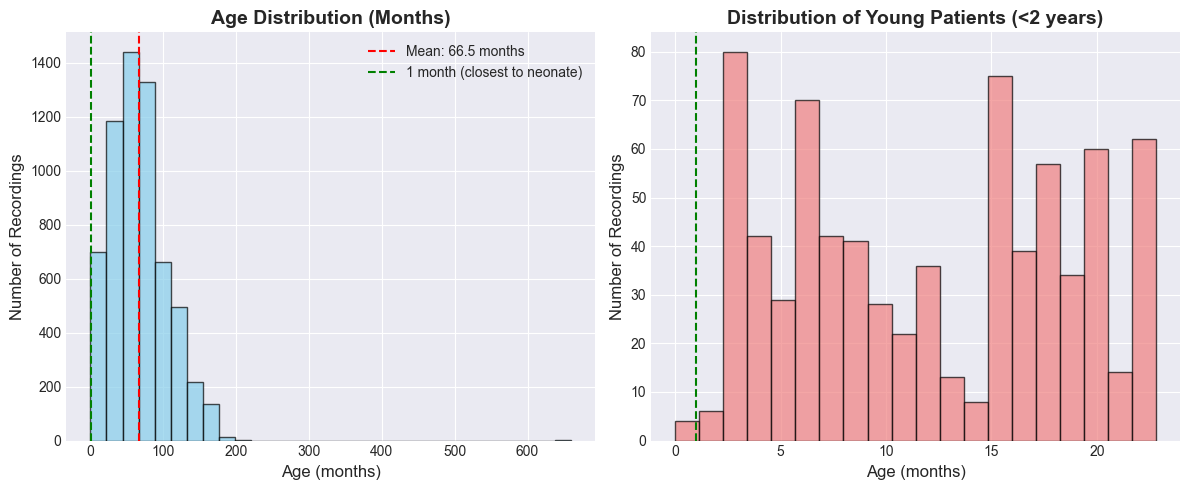

In [47]:
print("\n" + "="*60)
print("Visualization 1: Age Distribution")
print("="*60)

# Convert age from years to months for better interpretation
df_files['age_months'] = df_files['age'] * 12

print(f"Age in months - Min: {df_files['age_months'].min():.1f}, Max: {df_files['age_months'].max():.1f}, Mean: {df_files['age_months'].mean():.1f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_files['age_months'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Age Distribution (Months)', fontsize=14, fontweight='bold')
plt.xlabel('Age (months)', fontsize=12)
plt.ylabel('Number of Recordings', fontsize=12)
plt.axvline(df_files['age_months'].mean(), color='red', linestyle='--', 
            label=f"Mean: {df_files['age_months'].mean():.1f} months")
plt.axvline(1, color='green', linestyle='--', label="1 month (closest to neonate)")
plt.legend()

plt.subplot(1, 2, 2)
# Focus on youngest patients (under 2 years)
young_patients = df_files[df_files['age_months'] < 24]
plt.hist(young_patients['age_months'], bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
plt.title('Distribution of Young Patients (<2 years)', fontsize=14, fontweight='bold')
plt.xlabel('Age (months)', fontsize=12)
plt.ylabel('Number of Recordings', fontsize=12)
plt.axvline(1, color='green', linestyle='--', label="1 month")

plt.tight_layout()
plt.savefig(figures_dir / 'sprsound02_age_dist.png', dpi=150, bbox_inches='tight')
plt.show()

 ### Visualization 2: Gender Distribution


Visualization 2: Gender Distribution
gender
0    3323
1    2854
Name: count, dtype: int64


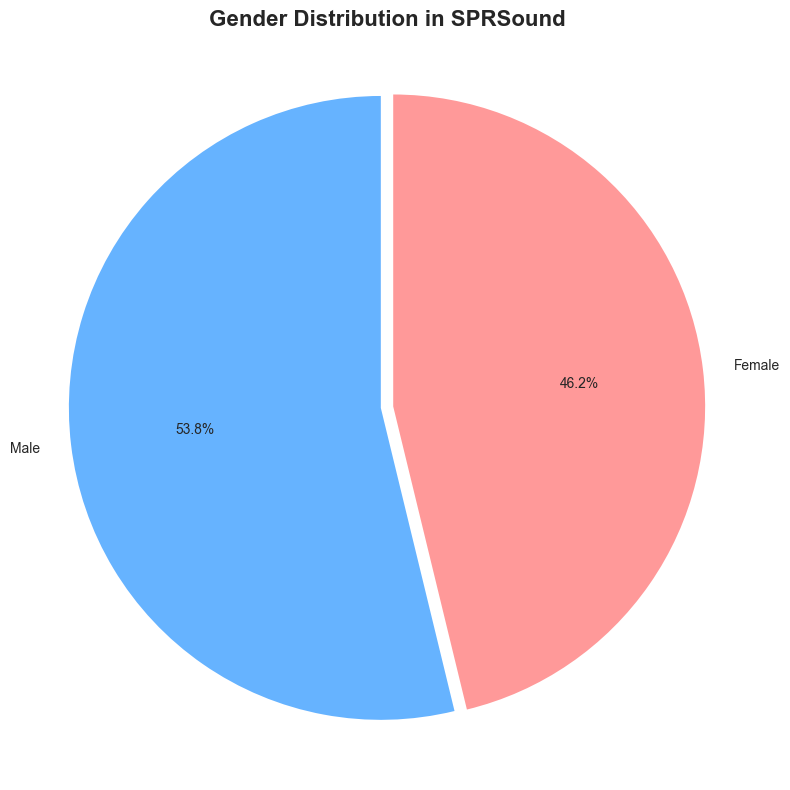

In [48]:
print("\n" + "="*60)
print("Visualization 2: Gender Distribution")
print("="*60)

gender_counts = df_files['gender'].value_counts()
print(gender_counts)

plt.figure(figsize=(8, 8))
colors = ['#66b3ff', '#ff9999']
plt.pie(gender_counts.values, labels=['Male', 'Female'], autopct='%1.1f%%',
        colors=colors, startangle=90, explode=[0.02, 0.02])
plt.title('Gender Distribution in SPRSound', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.savefig(figures_dir / 'sprsound03_gender_pie.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualization 3: Recording Location Distribution


Visualization 3: Chest Location Distribution
location
p2    1595
p1    1572
p4    1514
p3    1496
Name: count, dtype: int64


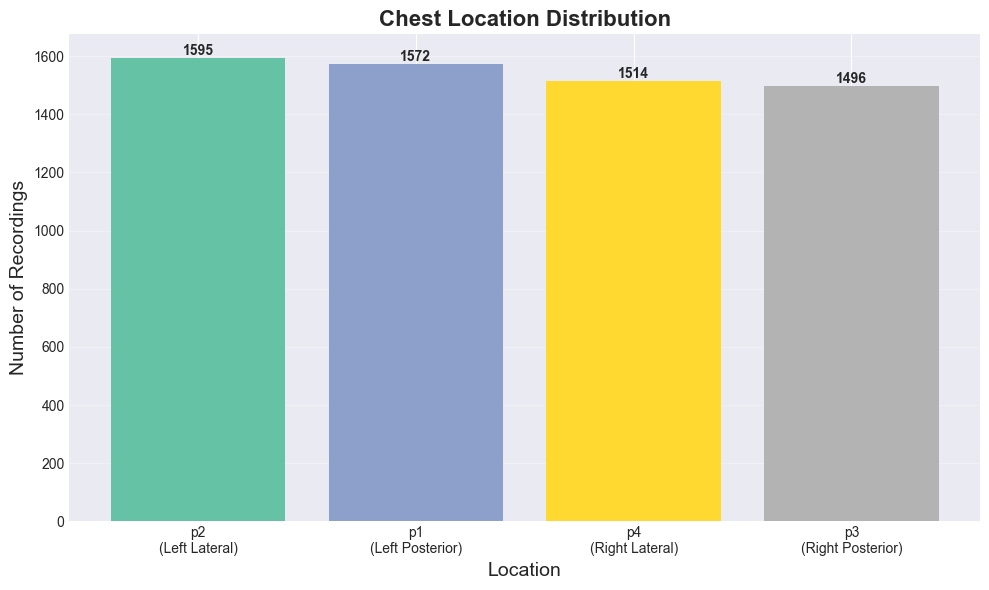

In [49]:
print("\n" + "="*60)
print("Visualization 3: Chest Location Distribution")
print("="*60)

location_counts = df_files['location'].value_counts()
print(location_counts)

# Decode location codes
location_names = {
    'p1': 'Left Posterior',
    'p2': 'Left Lateral', 
    'p3': 'Right Posterior',
    'p4': 'Right Lateral'
}

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(location_counts)), location_counts.values, 
               color=plt.cm.Set2(np.linspace(0, 1, len(location_counts))))
plt.title('Chest Location Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Location', fontsize=14)
plt.ylabel('Number of Recordings', fontsize=14)
plt.xticks(range(len(location_counts)), 
           [f"{code}\n({location_names.get(code, code)})" for code in location_counts.index])
plt.grid(True, alpha=0.3, axis='y')

for i, (bar, val) in enumerate(zip(bars, location_counts.values)):
    plt.text(i, val + 10, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(figures_dir / 'sprsound04_location_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Load and Parse JSON Annotations

In [35]:
def parse_sprsound_annotation(json_path):
    # Parse SPRSound JSON annotation file - handles string values
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        recording_label = data.get('recording_annotation', 'Unknown')
        
        events = []
        for event in data.get('event_annotation', []):
            # Convert start and end to float (they might be strings)
            start = event.get('start', 0)
            end = event.get('end', 0)
            
            # Convert to float if they're strings
            if isinstance(start, str):
                start = float(start)
            if isinstance(end, str):
                end = float(end)
            
            duration = end - start
            
            events.append({
                'annotation_file': json_path.name,
                'recording_file': json_path.stem + '.wav',
                'start_ms': start,
                'end_ms': end,
                'duration_ms': duration,
                'event_type': event.get('type', 'Unknown')
            })
        
        return recording_label, events
    except Exception as e:
        # Silent fail for EDA - just return empty
        return None, []

# Parse a sample of JSON files
print("\n" + "="*60)
print("Parsing JSON Annotations")
print("="*60)

# Take a sample of JSON files
sample_size = min(50, len(json_files))
sample_jsons = json_files[:sample_size]

all_events = []
recording_labels = []
success_count = 0

for json_path in sample_jsons:
    recording_label, events = parse_sprsound_annotation(json_path)
    if recording_label and len(events) > 0:
        recording_labels.append(recording_label)
        all_events.extend(events)
        success_count += 1

# Create DataFrame only if we have events
if len(all_events) > 0:
    df_events = pd.DataFrame(all_events)
    print(f"Successfully parsed {len(df_events)} events from {success_count} annotation files")
    print(f"\nEvent type distribution:")
    print(df_events['event_type'].value_counts())
else:
    df_events = pd.DataFrame()  # Empty DataFrame
    print(f"No events parsed from {sample_size} files. Using file-level labels only.")


Parsing JSON Annotations
Successfully parsed 133 events from 45 annotation files

Event type distribution:
event_type
Normal    130
Wheeze      3
Name: count, dtype: int64


## 7. Visualizations_2

### Visualization 4: Event-Level Labels


Visualization 4: Event-Level Label Distribution
event_type
Normal    130
Wheeze      3
Name: count, dtype: int64


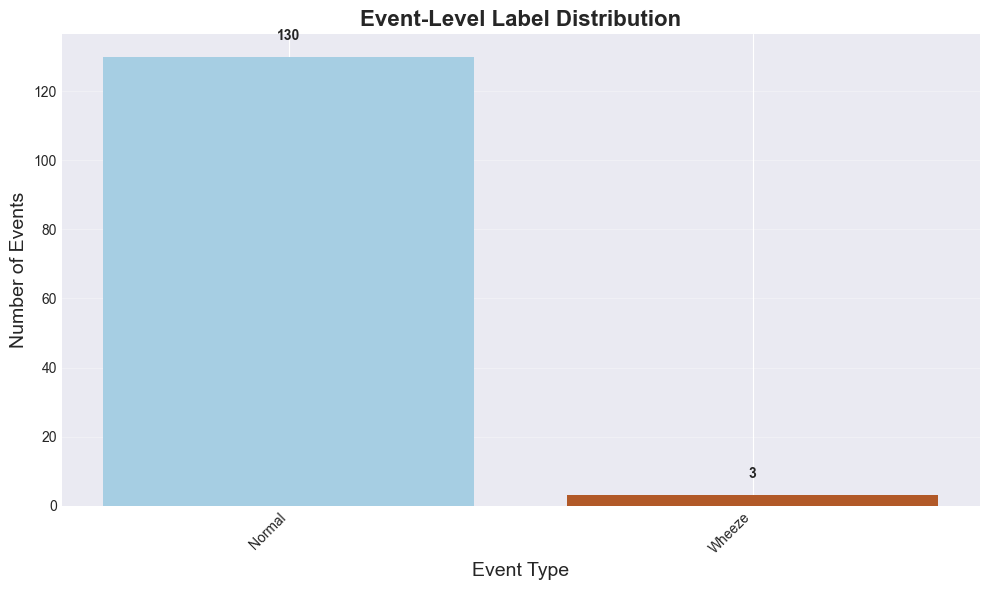

In [50]:
if len(df_events) > 0:
    print("\n" + "="*60)
    print("Visualization 4: Event-Level Label Distribution")
    print("="*60)
    
    event_counts = df_events['event_type'].value_counts()
    print(event_counts)
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(range(len(event_counts)), event_counts.values, 
                   color=plt.cm.Paired(np.linspace(0, 1, len(event_counts))))
    plt.title('Event-Level Label Distribution', fontsize=16, fontweight='bold')
    plt.xlabel('Event Type', fontsize=14)
    plt.ylabel('Number of Events', fontsize=14)
    plt.xticks(range(len(event_counts)), event_counts.index, rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    
    for i, (bar, val) in enumerate(zip(bars, event_counts.values)):
        plt.text(i, val + 5, str(val), ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(figures_dir / 'sprsound06_event_labels.png', dpi=150, bbox_inches='tight')
    plt.show()

### Symptom Mapping

In [45]:
if len(df_events) > 0:
    print("\n" + "="*60)
    print("Creating Symptom Labels from Events")
    print("="*60)
    
    # Map event types to symptom classes
    SYMPTOM_CLASSES = {
        'wheeze': 'Wheeze',
        'crackle': 'Crackles', 
        'rhonchi': 'Rhonchi',
        'stridor': 'Stridor',
        'normal': 'Normal',
        'coarse crackle': 'Crackles',
        'fine crackle': 'Crackles',
        'wheeze+crackle': 'Wheeze+Crackle'
    }
    
    # Create symptom class for each event - FIXED: using correct column name
    df_events['symptom_class'] = df_events['event_type'].str.lower().map(
        lambda x: next((v for k, v in SYMPTOM_CLASSES.items() if k in x), 'Other')
    )
    
    # Check if 'recording_file' column exists (it should from the parsing function)
    if 'recording_file' in df_events.columns:
        # Create recording-level labels (multi-label for mixed symptoms)
        recording_symptoms = df_events.groupby('recording_file')['symptom_class'].agg(
            lambda x: ' & '.join(sorted(set(x))) if len(set(x)) > 1 else list(x)[0]
        ).reset_index()
        recording_symptoms.columns = ['recording_file', 'combined_symptom']
        
        print(f"Created labels for {len(recording_symptoms)} recordings")
        print("\nSymptom distribution at recording level:")
        print(recording_symptoms['combined_symptom'].value_counts())
    else:
        print("'recording_file' column not found. Available columns:")
        print(df_events.columns.tolist())
else:
    print("No event data available for symptom labeling")


Creating Symptom Labels from Events
Created labels for 45 recordings

Symptom distribution at recording level:
combined_symptom
Normal             44
Normal & Wheeze     1
Name: count, dtype: int64


### Visualization 5: Event Duration Distribution


Visualization 5: Event Duration Distribution


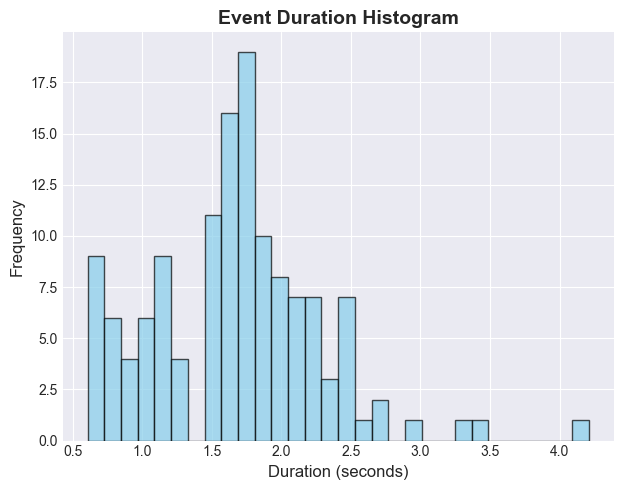

In [51]:
if len(df_events) > 0:
    print("\n" + "="*60)
    print("Visualization 5: Event Duration Distribution")
    print("="*60)
    
    # Convert ms to seconds
    df_events['duration_sec'] = df_events['duration_ms'] / 1000
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(df_events['duration_sec'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title('Event Duration Histogram', fontsize=14, fontweight='bold')
    plt.xlabel('Duration (seconds)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(figures_dir / 'sprsound07_event_durations.png', dpi=150, bbox_inches='tight')
    plt.show()

## 8. Audio Analysis Functions

In [53]:
def extract_audio_features(file_path):
    # Extract basic audio features from a WAV file
    try:
        y, sr = librosa.load(file_path, sr=None)
        duration = len(y) / sr
        
        features = {
            'file': file_path.name,
            'duration': duration,
            'sample_rate': sr,
            'samples': len(y),
            'rms_mean': np.mean(librosa.feature.rms(y=y)),
            'zcr_mean': np.mean(librosa.feature.zero_crossing_rate(y)),
            'spectral_centroid': np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        }
        
        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        for i in range(13):
            features[f'mfcc_{i+1}'] = np.mean(mfccs[i])
            
        return features, y, sr
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None, None, None

# Extract features from a sample of audio files
sample_wavs = wav_files[:50]
audio_features = []
for f in sample_wavs:
    features, _, _ = extract_audio_features(f)
    if features:
        audio_features.append(features)

df_audio = pd.DataFrame(audio_features)
print(f"Extracted features from {len(df_audio)} files")

Extracted features from 50 files


## 9. Visualizations_3

 ### Visualization 6: Duration Distribution


Visualization 6: Duration Distribution


<Figure size 1200x600 with 0 Axes>

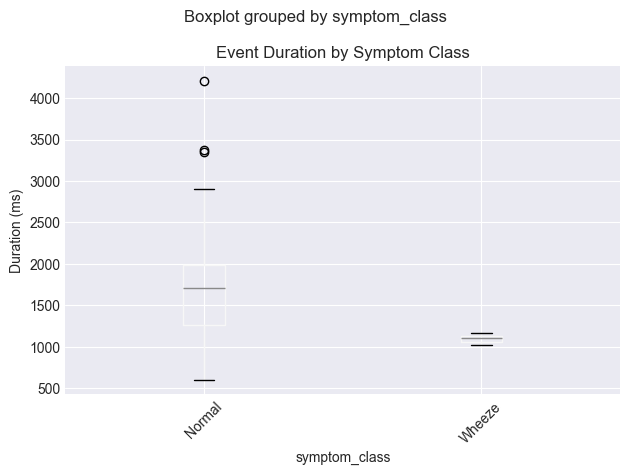

In [54]:
print("\n" + "="*60)
print("Visualization 6: Duration Distribution")
print("="*60)


# Analyze event durations by symptom class
if len(df_events) > 0:
    plt.figure(figsize=(12, 6))
    df_events.boxplot(column='duration_ms', by='symptom_class')
    plt.title('Event Duration by Symptom Class')
    plt.ylabel('Duration (ms)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(figures_dir / 'sprsound_duration_by_symptom.png', dpi=150, bbox_inches='tight')
    plt.show()

### Visualization 7: Sample Waveforms by Age Group


Visualization 7: Sample Waveforms by Age Group


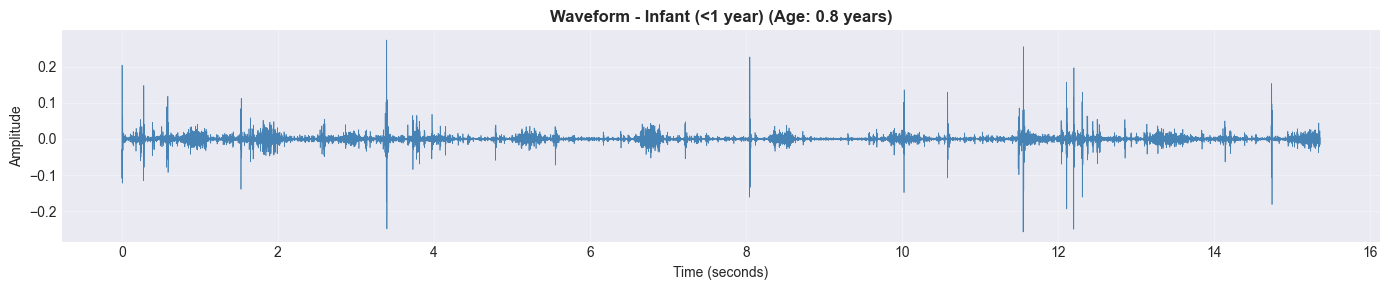

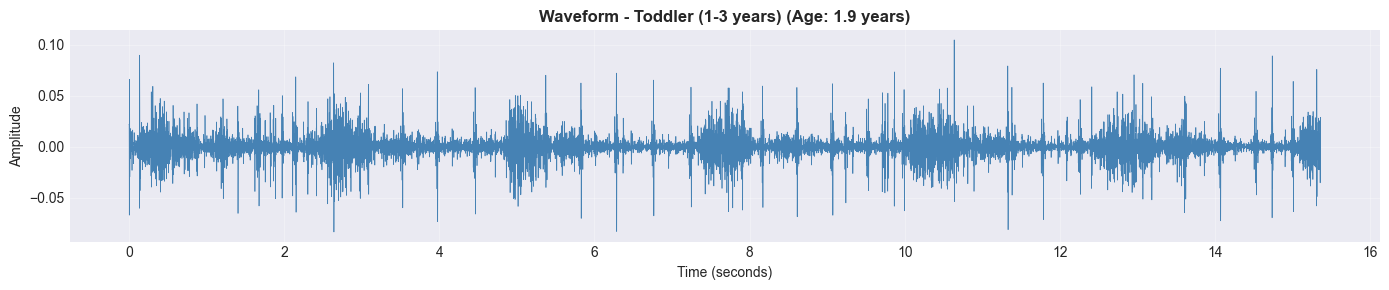

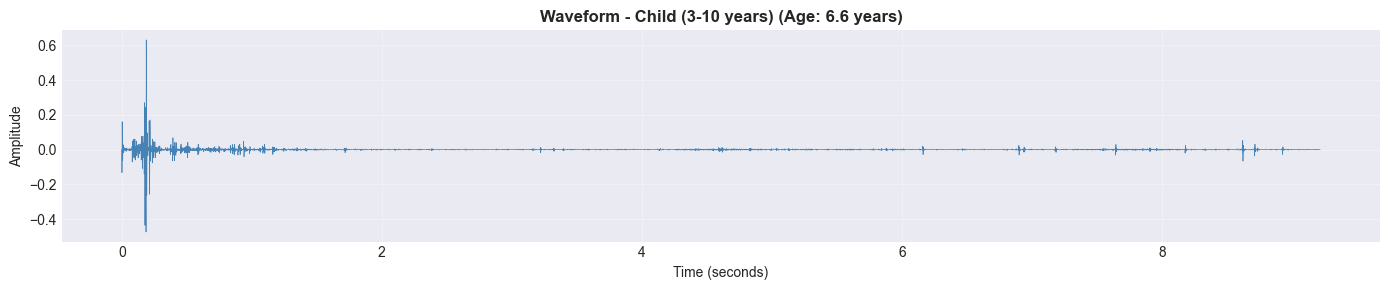

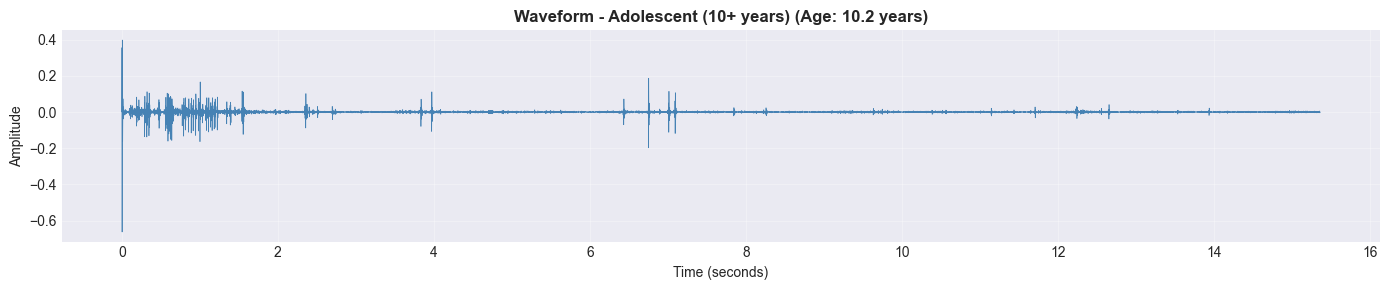

In [55]:
print("\n" + "="*60)
print("Visualization 7: Sample Waveforms by Age Group")
print("="*60)

age_groups = [
    ('Infant (<1 year)', df_files[df_files['age'] < 1]),
    ('Toddler (1-3 years)', df_files[(df_files['age'] >= 1) & (df_files['age'] < 3)]),
    ('Child (3-10 years)', df_files[(df_files['age'] >= 3) & (df_files['age'] < 10)]),
    ('Adolescent (10+ years)', df_files[df_files['age'] >= 10])
]

for group_name, group_df in age_groups:
    if len(group_df) > 0:
        # Pick a random file from this group
        sample = group_df.sample(1).iloc[0]
        file_path = Path(sample['full_path'])
        
        if file_path.exists():
            y, sr = librosa.load(file_path, sr=None)
            
            plt.figure(figsize=(14, 3))
            times = np.linspace(0, len(y)/sr, len(y))
            plt.plot(times, y, color='steelblue', linewidth=0.5)
            plt.title(f'Waveform - {group_name} (Age: {sample["age"]:.1f} years)', 
                     fontsize=12, fontweight='bold')
            plt.xlabel('Time (seconds)')
            plt.ylabel('Amplitude')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(figures_dir / f'sprsound09_waveform_{group_name.replace(" ", "_").replace("<", "under")}.png', 
                       dpi=150, bbox_inches='tight')
            plt.show()

### Visualization 8: MFCC Heatmap by Age Group


Visualization 8: MFCC Comparison by Age


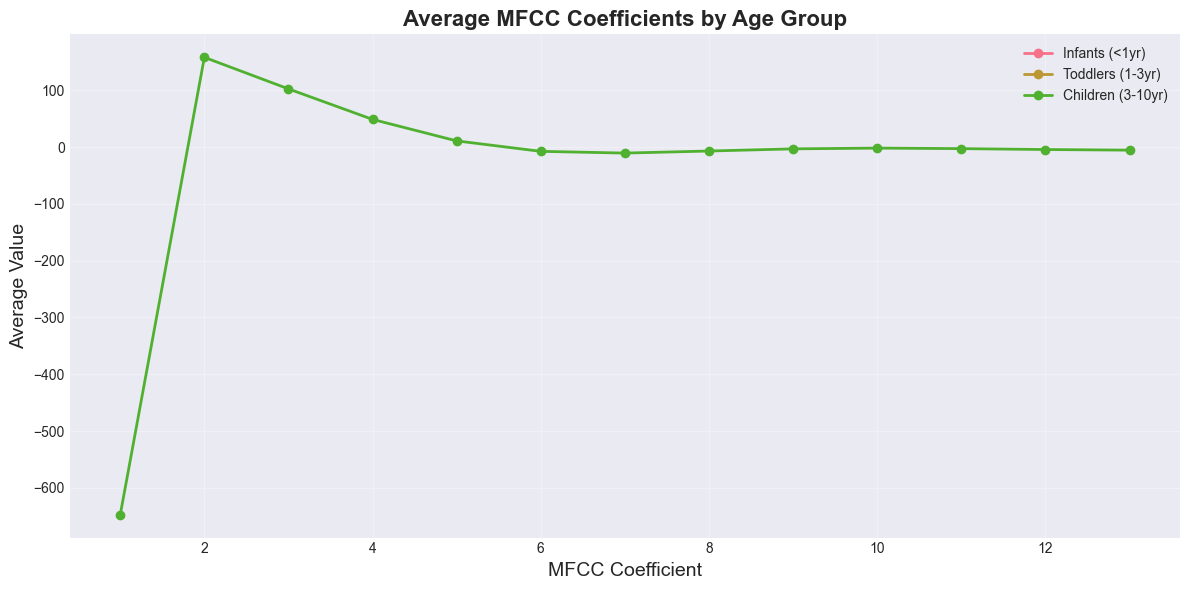

In [56]:
if len(df_audio) > 0 and len(df_files) > 0:
    print("\n" + "="*60)
    print("Visualization 8: MFCC Comparison by Age")
    print("="*60)
    
    # Merge audio features with metadata
    df_merged = pd.merge(df_audio, df_files, left_on='file', right_on='filename')
    
    # Group by age group
    age_groups = []
    mfcc_cols = [f'mfcc_{i+1}' for i in range(13)]
    
    for group_name, condition in [
        ('Infants (<1yr)', df_merged['age'] < 1),
        ('Toddlers (1-3yr)', (df_merged['age'] >= 1) & (df_merged['age'] < 3)),
        ('Children (3-10yr)', (df_merged['age'] >= 3) & (df_merged['age'] < 10))
    ]:
        group_data = df_merged[condition][mfcc_cols].mean().values
        if len(group_data) > 0:
            age_groups.append((group_name, group_data))
    
    if age_groups:
        plt.figure(figsize=(12, 6))
        for group_name, mfcc_vals in age_groups:
            plt.plot(range(1, 14), mfcc_vals, marker='o', linewidth=2, label=group_name)
        
        plt.title('Average MFCC Coefficients by Age Group', fontsize=16, fontweight='bold')
        plt.xlabel('MFCC Coefficient', fontsize=14)
        plt.ylabel('Average Value', fontsize=14)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(figures_dir / 'sprsound10_mfcc_by_age.png', dpi=150, bbox_inches='tight')
        plt.show()

### Visualization 9: Train/Test Split Distribution


Visualization 9: Train/Test Split Distribution
split
test     4228
train    1949
Name: count, dtype: int64


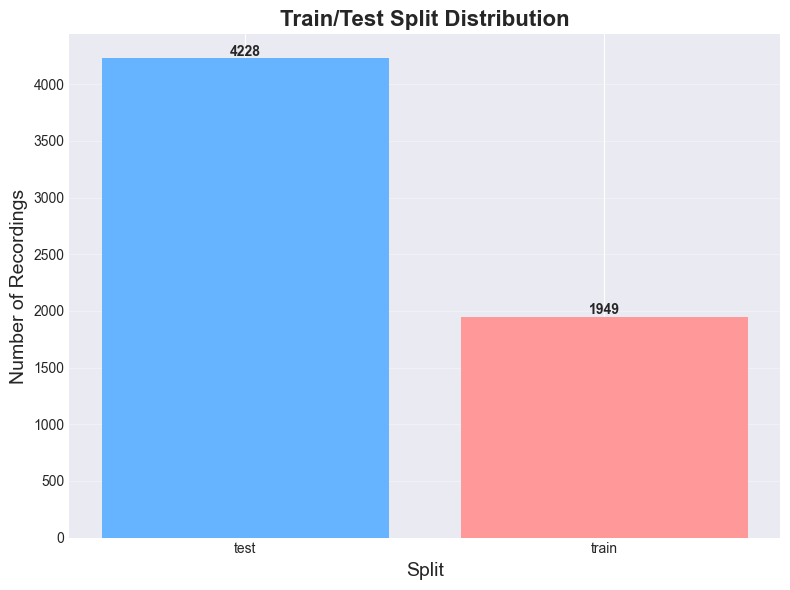

In [57]:
print("\n" + "="*60)
print("Visualization 9: Train/Test Split Distribution")
print("="*60)

split_counts = df_files['split'].value_counts()
print(split_counts)

plt.figure(figsize=(8, 6))
bars = plt.bar(range(len(split_counts)), split_counts.values, 
               color=['#66b3ff', '#ff9999'])
plt.title('Train/Test Split Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Split', fontsize=14)
plt.ylabel('Number of Recordings', fontsize=14)
plt.xticks(range(len(split_counts)), split_counts.index)
plt.grid(True, alpha=0.3, axis='y')

for i, (bar, val) in enumerate(zip(bars, split_counts.values)):
    plt.text(i, val + 20, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(figures_dir / 'sprsound11_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Complete Summary

In [62]:
print("\n" + "="*60)
print("SPRSOUND DATASET - COMPLETE SUMMARY")
print("="*60)

# File counts
total_wav = len(wav_files)
total_json = len(json_files)

# Patient statistics
unique_patients = df_files['patient_id'].nunique() if 'df_files' in locals() else 0
age_range = f"{df_files['age'].min():.1f} - {df_files['age'].max():.1f} years" if 'df_files' in locals() else 'N/A'

# Gender distribution
if 'df_files' in locals() and 'gender' in df_files.columns:
    gender_counts = df_files['gender'].value_counts()
    gender_str = f"M: {gender_counts.get('Male', 0)}, F: {gender_counts.get('Female', 0)}"
else:
    gender_str = 'N/A'

# Location distribution
if 'df_files' in locals() and 'location' in df_files.columns:
    locations = ', '.join(df_files['location'].unique())
else:
    locations = 'N/A'

# Year distribution
if 'df_files' in locals() and 'year' in df_files.columns:
    years = ', '.join(df_files['year'].unique())
else:
    years = 'N/A'

# Split distribution
if 'df_files' in locals() and 'split' in df_files.columns:
    split_counts = df_files['split'].value_counts()
    split_str = f"Train: {split_counts.get('train', 0)}, Test: {split_counts.get('test', 0)}"
else:
    split_str = 'N/A'

# Event statistics
if len(df_events) > 0:
    total_events = len(df_events)
    unique_event_types = df_events['event_type'].nunique()
    event_types_list = ', '.join(df_events['event_type'].unique())
else:
    total_events = 0
    unique_event_types = 0
    event_types_list = 'N/A'

# Create summary dataframe
summary = pd.DataFrame({
    'Metric': [
        'Total Audio Files',
        'Total JSON Files',
        'Unique Patients',
        'Age Range',
        'Gender Distribution',
        'Recording Locations',
        'Years Included',
        'Train/Test Split',
        'Total Events Parsed',
        'Unique Event Types',
        'Event Types'
    ],
    'Value': [
        total_wav,
        total_json,
        unique_patients,
        age_range,
        gender_str,
        locations,
        years,
        split_str,
        total_events,
        unique_event_types,
        event_types_list
    ]
})

print("\n", summary.to_string(index=False))

# Save summary
summary.to_csv(SPRSound_PATH / "sprsound_eda_summary.csv", index=False)
if 'df_files' in locals():
    df_files.to_csv(SPRSound_PATH / "sprsound_file_list.csv", index=False)

print(f"\n All visualizations saved to: {figures_dir}")
print(f" Summaries saved to: {SPRSound_PATH}/sprsound_eda_summary.csv")


SPRSOUND DATASET - COMPLETE SUMMARY

              Metric                   Value
  Total Audio Files                    6567
   Total JSON Files                    6567
    Unique Patients                     868
          Age Range        0.0 - 55.0 years
Gender Distribution              M: 0, F: 0
Recording Locations          p1, p2, p4, p3
     Years Included           test, unknown
   Train/Test Split Train: 1949, Test: 4228
Total Events Parsed                     133
 Unique Event Types                       2
        Event Types          Normal, Wheeze

 All visualizations saved to: ..\reports\figures\sprsound
 Summaries saved to: ..\sound_data\sprsound/sprsound_eda_summary.csv


## 12. Prepare Data for Modeling

In [64]:
def prepare_for_modeling(df_files, df_events):
    # Prepare SPRSound data for model training
    # Creates a feature matrix with one row per recording
    print("\n" + "="*60)
    print("PREPARING DATA FOR MODELING")
    print("="*60)
    
    # Start with file metadata
    recording_features = df_files.copy()
    
    # Create a unique recording key
    if 'filename' in recording_features.columns:
        recording_features['recording_key'] = recording_features['filename']
    else:
        recording_features['recording_key'] = recording_features['file']
    
    # Aggregate event info per recording
    if len(df_events) > 0:
        print(f"\nProcessing {len(df_events)} events from {df_events['recording_file'].nunique() if 'recording_file' in df_events.columns else 0} recordings...")
        
        # Check what columns we have
        print(f"df_events columns: {df_events.columns.tolist()}")
        
        if 'recording_file' in df_events.columns:
            # Group by recording_file
            event_stats = df_events.groupby('recording_file').agg({
                'duration_ms': ['count', 'mean', 'sum'],
                'event_type': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'
            }).reset_index()
            
            # Flatten column names
            event_stats.columns = ['recording_file', 'event_count', 'avg_event_duration', 
                                  'total_event_duration', 'primary_event_type']
            
            print(f"Created event statistics for {len(event_stats)} recordings")
            
            # Merge with recording features
            recording_features = recording_features.merge(
                event_stats, 
                left_on='recording_key', 
                right_on='recording_file', 
                how='left'
            )
        else:
            print("'recording_file' column not found in df_events")
    else:
        print("No event data available")
    
    # Fill NaN values
    for col in ['event_count', 'avg_event_duration', 'total_event_duration']:
        if col in recording_features.columns:
            recording_features[col] = recording_features[col].fillna(0)
    
    if 'primary_event_type' in recording_features.columns:
        recording_features['primary_event_type'] = recording_features['primary_event_type'].fillna('Unknown')
    
    print(f"\nFinal feature matrix shape: {recording_features.shape}")
    print(f"Columns: {recording_features.columns.tolist()}")
    
    return recording_features

# Prepare data
if 'df_files' in locals():
    model_ready_df = prepare_for_modeling(df_files, df_events if 'df_events' in locals() else pd.DataFrame())
    
    # Save to CSV
    model_ready_df.to_csv(SPRSound_PATH / "sprsound_model_ready.csv", index=False)
    print(f"\nModel-ready data saved to: {SPRSound_PATH}/sprsound_model_ready.csv")
    
    # Show summary
    print("\nData Summary for Modeling:")
    print(f"Total recordings: {len(model_ready_df)}")
    if 'primary_event_type' in model_ready_df.columns:
        print("\nPrimary event type distribution:")
        print(model_ready_df['primary_event_type'].value_counts())
else:
    print("df_files not available")


PREPARING DATA FOR MODELING

Processing 133 events from 45 recordings...
df_events columns: ['annotation_file', 'recording_file', 'start_ms', 'end_ms', 'duration_ms', 'event_type', 'symptom_class', 'duration_sec']
Created event statistics for 45 recordings

Final feature matrix shape: (6177, 16)
Columns: ['filename', 'patient_id', 'age', 'gender', 'location', 'recording_id', 'year', 'split', 'full_path', 'age_months', 'recording_key', 'recording_file', 'event_count', 'avg_event_duration', 'total_event_duration', 'primary_event_type']

Model-ready data saved to: ..\sound_data\sprsound/sprsound_model_ready.csv

Data Summary for Modeling:
Total recordings: 6177

Primary event type distribution:
primary_event_type
Unknown    6132
Normal       45
Name: count, dtype: int64
